In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')

# Fixar seeds
torch.manual_seed(42)
np.random.seed(42)

# Carregar e limpar dataset
df = pd.read_csv(r'C:\Users\thayn\fiap-tech-challenge-churn\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()

# Salvar dataset limpo
df.to_csv(r'C:\Users\thayn\fiap-tech-challenge-churn\data\processed\telco_clean.csv', index=False)

# Features
FEATURES_NUM = ['tenure', 'MonthlyCharges', 'TotalCharges']
FEATURES_CAT = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling', 'PaymentMethod']

X = df[FEATURES_NUM + FEATURES_CAT]
y = (df['Churn'] == 'Yes').astype(int).values

print("Dataset carregado!")
print(f"Shape: {X.shape}")
print(f"Churn positivo: {y.sum()} ({y.mean():.1%})")

Dataset carregado!
Shape: (7032, 18)
Churn positivo: 1869 (26.6%)


In [6]:
# Pipeline de pré-processamento
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])

# Dividir dados
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Aplicar pré-processamento
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Treino:    {X_train_proc.shape}")
print(f"Validação: {X_val_proc.shape}")
print(f"Teste:     {X_test_proc.shape}")
print(f"\nNº de features após encoding: {X_train_proc.shape[1]}")

Treino:    (4922, 44)
Validação: (1055, 44)
Teste:     (1055, 44)

Nº de features após encoding: 44


In [7]:
# Dataset PyTorch
class ChurnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoaders
train_dataset = ChurnDataset(X_train_proc, y_train)
val_dataset = ChurnDataset(X_val_proc, y_val)
test_dataset = ChurnDataset(X_test_proc, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Modelo MLP
class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# Instanciar modelo
input_dim = X_train_proc.shape[1]
model = ChurnMLP(input_dim)

print(model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model.parameters()):,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total de parâmetros: 4,993


In [8]:
from sklearn.metrics import roc_auc_score

# Configurações
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Early stopping
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_model_state = None

# Histórico
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print("Iniciando treinamento...")
print("-" * 50)

for epoch in range(100):
    # Treino
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validação
    model.eval()
    val_loss = 0
    val_preds = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            val_loss += criterion(y_pred, y_batch).item()
            val_preds.extend(y_pred.numpy())
    val_loss /= len(val_loader)
    val_auc = roc_auc_score(y_val, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping na época {epoch+1}!")
        break

# Carregar melhor modelo
model.load_state_dict(best_model_state)
print("\nMelhor modelo carregado!")

Iniciando treinamento...
--------------------------------------------------
Época  10 | Train Loss: 0.4163 | Val Loss: 0.4129 | Val AUC: 0.8510

Early stopping na época 14!

Melhor modelo carregado!


In [9]:
import joblib
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report

# Avaliação no conjunto de teste
model.eval()
test_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        test_preds.extend(y_pred.numpy())

test_preds = np.array(test_preds)
test_labels = (test_preds >= 0.5).astype(int)

auc = roc_auc_score(y_test, test_preds)
f1 = f1_score(y_test, test_labels)
pr_auc = average_precision_score(y_test, test_preds)

print("=== RESULTADOS NO TESTE ===")
print(f"AUC-ROC: {auc:.4f}")
print(f"F1:      {f1:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"\n{classification_report(y_test, test_labels)}")

# Registrar no MLflow
mlflow.set_experiment("churn-mlp")
with mlflow.start_run(run_name="ChurnMLP"):
    mlflow.log_param("arquitetura", "44-64-32-1")
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("lr", 0.001)
    mlflow.log_param("batch_size", 64)
    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("pr_auc", pr_auc)
    
    # Salvar modelo
    torch.save(model.state_dict(), 
               r'C:\Users\thayn\fiap-tech-challenge-churn\models\mlp_churn.pt')
    mlflow.log_artifact(
               r'C:\Users\thayn\fiap-tech-challenge-churn\models\mlp_churn.pt')
    
    # Salvar pipeline
    joblib.dump(preprocessor, 
                r'C:\Users\thayn\fiap-tech-challenge-churn\models\preprocessor.pkl')

print("\n✅ Modelo registrado no MLflow!")

=== RESULTADOS NO TESTE ===
AUC-ROC: 0.8205
F1:      0.5187
PR-AUC:  0.5826

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       775
           1       0.62      0.45      0.52       280

    accuracy                           0.78      1055
   macro avg       0.72      0.67      0.69      1055
weighted avg       0.77      0.78      0.77      1055



2026/05/05 19:44:32 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.



✅ Modelo registrado no MLflow!


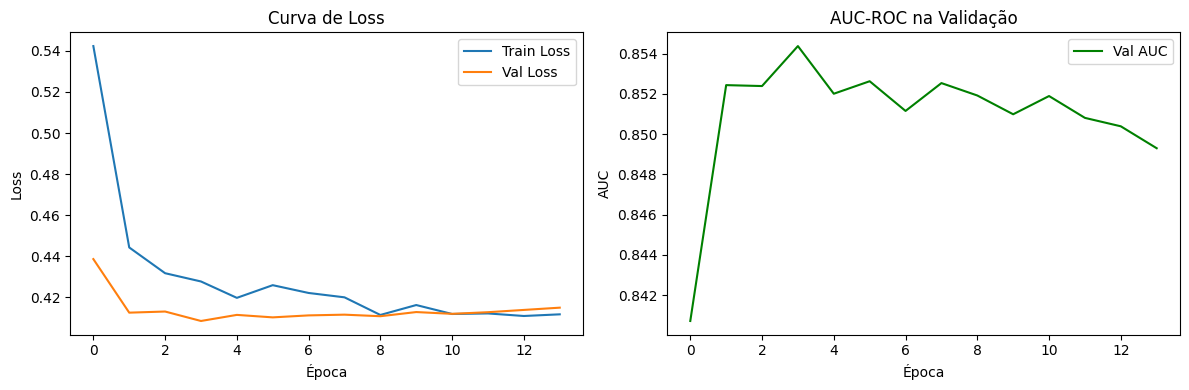

In [11]:
import matplotlib.pyplot as plt

# Curva de aprendizado
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Curva de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='Val AUC', color='green')
plt.title('AUC-ROC na Validação')
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()